In [28]:
from get_cutouts import get_cutout

from astropy.table import Table
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
'''
import sys
sys.path.insert(1, '{}/desi/DESI_SGA/'.format(os.environ['HOME']))
try:
    from plot_funcs import plot_radec_DESI
except ModuleNotFoundError as e:
    print(e)
''';
import psycopg2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from astropy.coordinates import SkyCoord, match_coordinates_sky

from glob import glob

from scipy.ndimage import gaussian_filter1d

from desispec.io import read_spectra
from desispec.spectra import stack as specstack
from desispec.coaddition import coadd_cameras

pix_scale = 0.25 # arcsec/pixel

import matplotlib.patheffects as patheffects
from tqdm import tqdm

# This is importing get_cutouts and using that function

## Data

In [29]:
target_galaxies = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_targs.fits')
target_galaxies[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,1
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,1
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,1
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,1
2389190650101761,49.636675196299485,-14.026544506699297,0.01713651665060884,2.0408204503181013e-05,GALAXY,56.60990794678219,0,TFT,1074364,S,0.0026515899552215774,0.40000000679324754,1


In [30]:
SGA = Table.read('/global/cfs/projectdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

## Table of sga id for only the loa targets

In [31]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

In [32]:
#creates empty columns to add to target_galaxies for classifications
SGA['loa'] = 0

for i in tqdm(np.unique(target_galaxies['SGA_ID'])):

    #identify all gaalxy targets
    targ_id = target_galaxies['SGA_ID'] == i

    #find the index for this target in SGA
    sga_id = SGA_dict[i]

    SGA['loa'][sga_id] = 1

100%|██████████| 1124/1124 [00:00<00:00, 20498.90it/s]


In [33]:
SGA_loa = SGA[SGA['loa']==1]
SGA_loa[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,loa
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,int64
425,SGA-2020 425,PGC049409,49409,208.542678,44.2133617,SBbc,30.13,0.3981072,0.8128305,0.06368206,22.381481,15.753,False,LEDA-20181114,121,PGC049409_GROUP,2,True,208.54602188490358,44.21081193404006,0.6080715,2083p442,208.54261517279625,44.21336719329461,0.5329004,SB26,29.398323,0.76350456,208.54244265884032,44.2135020286059,13.286062,4.910831,4.4874635,2.994671,7.906555,9.092144,10.197503,11.260192,12.233587,13.004084,14.062565,14.935026,15.987012,15.997503,15.3831835,14.9915285,15.892004,15.285641,14.910577,15.828795,15.227365,14.861485,15.7904625,15.190083,14.831137,15.766502,15.166609,14.814155,15.752086,15.153393,14.806333,15.74006,15.14252,14.803116,15.73508,15.138399,14.805074,15.732069,15.134918,14.809265,0.035009358,0.05021873,0.048667938,0.053922795,0.10604824,0.10777367,0.12476239,0.10753901,0.14136124,0.012058165,0.013741603,0.020537226,0.011274149,0.01279831,0.019184649,0.010805588,0.012251667,0.018415827,0.010514686,0.0119154025,0.017966362,0.0103335725,0.011707147,0.017724745,0.01023792,0.011560682,0.01748609,0.010143652,0.011465001,0.017451182,0.010105025,0.011431337,0.017492471,0.010082828,0.011399948,0.01756689,15.719012,0.19571984,0.83850664,5.6243095,0.10244078,15.124254,0.15408316,1.0596911,6.013549,0.07396622,14.803934,0.0495287,2.64035,11.796646,0.19014192,0,1
5568,SGA-2020 5568,NGC5313,49069,207.43480200000002,39.9847415,SABb,42.1,1.8113401,0.5821032,0.008472527,22.567482,12.649,False,LEDA-20181114,1495,NGC5313,1,True,207.43480200000002

## Extract Galaxy Data

In [34]:
galaxy_to_plot = 'PGC049409'

# Find the galaxy's SGA_ID
galaxy_sgaid = SGA['SGA_ID'][SGA['GALAXY'] == galaxy_to_plot][0]

# Find all of the observations of this galaxy in the data
galaxy_obs = target_galaxies[target_galaxies['SGA_ID'] == galaxy_sgaid]
galaxy_obs

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64
2403689889267713,208.54383176082783,44.21491477959921,0.06355521207306254,1.7422030931386313e-06,GALAXY,8729.815555334091,0,TFT,425,N,0.0017763346118598443,0.39999999290581684,1
39633153605766206,208.54261517279625,44.21336719329461,0.0636444535394323,1.3282742875980788e-06,GALAXY,40970.01239442825,0,TFT,425,N,0.0,0.0,1
2305843020408297564,208.54267343398516,44.21336986486924,0.06364551496692648,1.785243733139245e-06,GALAXY,15354.668297290802,0,TFT,425,N,4.184395803311205e-05,0.009422539427338896,1


### Find target id of center observation

In [35]:
first_digits = np.trunc(galaxy_obs['TARGETID'] * 10**(-np.trunc(np.log10(galaxy_obs['TARGETID'])))).astype(int)

center = galaxy_obs[first_digits == 3]
center

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64
39633153605766206,208.54261517279625,44.21336719329461,0.0636444535394323,1.3282742875980788e-06,GALAXY,40970.01239442825,0,TFT,425,N,0.0,0.0,1


## Grab image of galaxy and put the observations on it

### This code seems to place all the fibers, but not the image

image_dir_sga_39633153605766206.jpg exists.


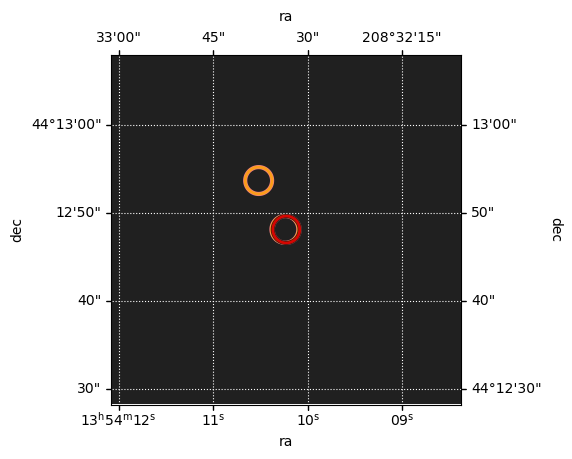

In [10]:
# Padd the image cutout of the galaxy.
# Multiply by 60 (to arcsec), divide by 180 to get pixscale.
# pixscale = 1.05*(SGA['SGA_ID'][SGA['GALAXY'] == galaxy_to_plot][0])*60/180
npix = np.minimum(int(1.25 * SGA['D26'][SGA['GALAXY'] == galaxy_to_plot][0]*60/0.262), 512)

img_file, wcs = get_cutout(center['TARGETID'][0], 
                           center['TARGET_RA'][0], 
                           center['TARGET_DEC'][0], 
                           size=npix, 
                           verbose=True)

img = mpl.image.imread(img_file)

fig1 = plt.figure(figsize=(7,5))

ax = fig1.add_subplot(111, projection=wcs)
ax.imshow(np.flip(img, axis=0))
ax.set(xlabel='ra', ylabel='dec')
#ax.text(int(0.02*npix), int(0.85*npix), 'TARGETID: {}\nSGA_ID: {}\n$z={{{:.4f}}}$'.format(targetid, sga_id, z), fontsize=9, color='yellow')
overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='white', ls='dotted')

for tft in galaxy_obs:
    ra, dec = tft['TARGET_RA'], tft['TARGET_DEC']

    edgecolor2 = 'orange'
    if tft['Z'] > 0.05:
        edgecolor2 = 'orange'
    else:
        edgecolor2 = 'lime'

    # Add the location of the DESI fibers.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), 107./70 * u.arcsec,
                         edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), 107./70 * u.arcsec,
                         edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)

# Add the location of the DESI fibers.
# SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
r1 = SphericalCircle((center['TARGET_RA'][0] * u.deg, center['TARGET_DEC'][0] * u.deg), 107./70 * u.arcsec,
                     edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                     transform=ax.get_transform('icrs'))
r2 = SphericalCircle((center['TARGET_RA'][0] * u.deg, center['TARGET_DEC'][0] * u.deg), 107./70 * u.arcsec,
                     edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                     transform=ax.get_transform('icrs'))

ax.add_patch(r1)
ax.add_patch(r2)

fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)

### This code places the image and center fiber, but no other fibers

image_dir_sga_425.jpg exists.


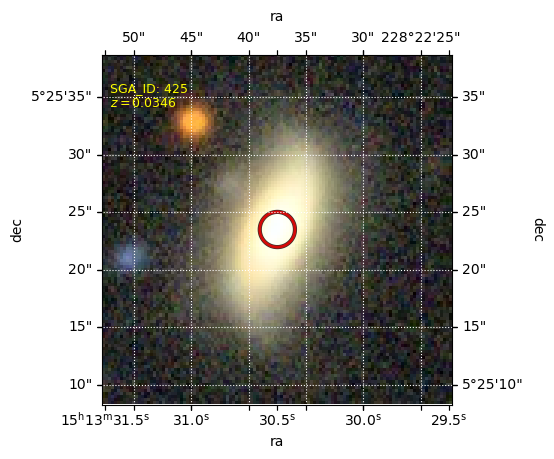

In [18]:
for i in range(1):
    
    # Retrieve SGA ID of galaxy
    sga_id = SGA_loa['SGA_ID'][i]
    
    # Coordinates of SGA galaxy's center   
    ra, dec, z = float(SGA['RA'][i]), float(SGA['DEC'][i]), float(SGA['Z_LEDA'][i])
    
    # D26 in arcmin
    d26 = SGA['D26'][i]
    
    #---------------------------------------------------------------------------
    # Padd the image cutout of the galaxy.
    # Multiply by 60 (to arcsec), divide by 180 to get pixscale.
    npix = np.minimum(int(1.025 * d26*60/0.262), 512)
    
    #print(targetid, sga_id, ra, dec)
    img_file, wcs = get_cutout(sga_id, ra, dec, npix, verbose=True)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot(111, projection=wcs)
    ax.imshow(np.flip(img, axis=0))
    ax.set(xlabel='ra', ylabel='dec')
    ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}\n$z={{{:.4f}}}$'.format(sga_id, z), fontsize=9, color='yellow')
    overlay = ax.get_coords_overlay('icrs')
    overlay.grid(color='white', ls='dotted');
    #---------------------------------------------------------------------------
    
    #---------------------------------------------------------------------------
    # Add the location of the center DESI fiber.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)
    #---------------------------------------------------------------------------

    tf_list = target_galaxies[target_galaxies['SGA_ID'] == sga_id]
    
    # Only keep targets at 0.4R26
    SGA_coords = SkyCoord(ra=ra, dec=dec, unit=u.degree)
    target_coords = SkyCoord(ra=tf_list['TARGET_RA'], dec=tf_list['TARGET_DEC'], unit=u.degree)
    sep2d = target_coords.separation(SGA_coords)
    sep2d_r26 = 2*sep2d.to('arcmin')/(d26*u.arcmin)
    tf_list_0p4 = tf_list[(sep2d_r26 > 0.35) & (sep2d_r26 < 0.45)]

    for i in range(len(tf_list_0p4)):
        ra, dec = tf_list_0p4['RA'][i], tf_list_0p4['DEC'][i]
        
        edgecolor2 = 'orange'
        
        # Add the location of the DESI fibers.
        # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
        r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                             transform=ax.get_transform('icrs'))
        r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                             transform=ax.get_transform('icrs'))
        ax.add_patch(r1)
        ax.add_patch(r2)
        
        ax.text(ra, dec, str(tf_list_0p4['TARGETID'][i]), 
                transform=ax.get_transform('icrs'), 
                color='white', 
                path_effects=[patheffects.withStroke(linewidth=1, foreground='black')])
    
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    #fig1.savefig('/pscratch/sd/d/dbustos/rot_curves'.format(sga_id), dpi=120)
    
    #fig1.clear()
    #plt.close(fig1)

### This is a mix of both codes to try to fix it
it's not working...

Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=228.3770803831908&dec=5.423191398593787&%22/pix=0.25&layer=ls-dr11-early-v2&size=116&zoom=14&sga2020


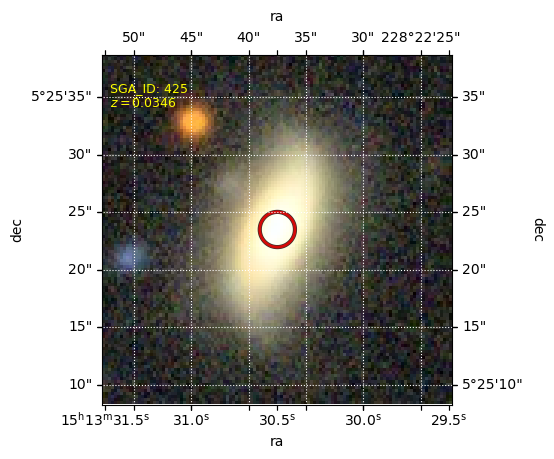

In [36]:
for i in range(1):
    
    # Retrieve SGA ID of galaxy
    sga_id = SGA_loa['SGA_ID'][i]
    
    # Coordinates of SGA galaxy's center   
    ra, dec, z = float(SGA['RA'][i]), float(SGA['DEC'][i]), float(SGA['Z_LEDA'][i])
    
    # D26 in arcmin
    d26 = SGA['D26'][i]
    
    #---------------------------------------------------------------------------
    # Padd the image cutout of the galaxy.
    # Multiply by 60 (to arcsec), divide by 180 to get pixscale.
    npix = np.minimum(int(1.025 * d26*60/0.262), 512)
    
    #print(targetid, sga_id, ra, dec)
    img_file, wcs = get_cutout(sga_id, ra, dec, npix, verbose=True)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot(111, projection=wcs)
    ax.imshow(np.flip(img, axis=0))
    ax.set(xlabel='ra', ylabel='dec')
    ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}\n$z={{{:.4f}}}$'.format(sga_id, z), fontsize=9, color='yellow')
    overlay = ax.get_coords_overlay('icrs')
    overlay.grid(color='white', ls='dotted');
    #---------------------------------------------------------------------------
    
    #---------------------------------------------------------------------------
    # Add the location of the center DESI fiber.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)
    #---------------------------------------------------------------------------

    tf_list = target_galaxies[target_galaxies['SGA_ID'] == sga_id]
    
    # Only keep targets at 0.4R26
    SGA_coords = SkyCoord(ra=ra, dec=dec, unit=u.degree)
    target_coords = SkyCoord(ra=tf_list['TARGET_RA'], dec=tf_list['TARGET_DEC'], unit=u.degree)
    sep2d = target_coords.separation(SGA_coords)
    sep2d_r26 = 2*sep2d.to('arcmin')/(d26*u.arcmin)
    tf_list_0p4 = tf_list[(sep2d_r26 > 0.35) & (sep2d_r26 < 0.45)]

    for i in tf_list:
        ra, dec = i['TARGET_RA'], i['TARGET_DEC']
        
        edgecolor2 = 'orange'
        
        # Add the location of the DESI fibers.
        # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
        r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                             transform=ax.get_transform('icrs'))
        r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                             transform=ax.get_transform('icrs'))
        ax.add_patch(r1)
        ax.add_patch(r2)
        
        # ax.text(ra, dec, str(tf_list['TARGETID'][i]), 
        #         transform=ax.get_transform('icrs'), 
        #         color='white', 
        #         path_effects=[patheffects.withStroke(linewidth=1, foreground='black')])

    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    #fig1.savefig('/pscratch/sd/d/dbustos/rot_curves'.format(sga_id), dpi=120)
    
    #fig1.clear()
    #plt.close(fig1)

### This is stolen code from somewhere else

Also not working, but also giving funkier answers, so maybe something is very wrong...

image_dir_sga_425.jpg exists.
image_dir_sga_5568.jpg exists.
image_dir_sga_7474.jpg exists.


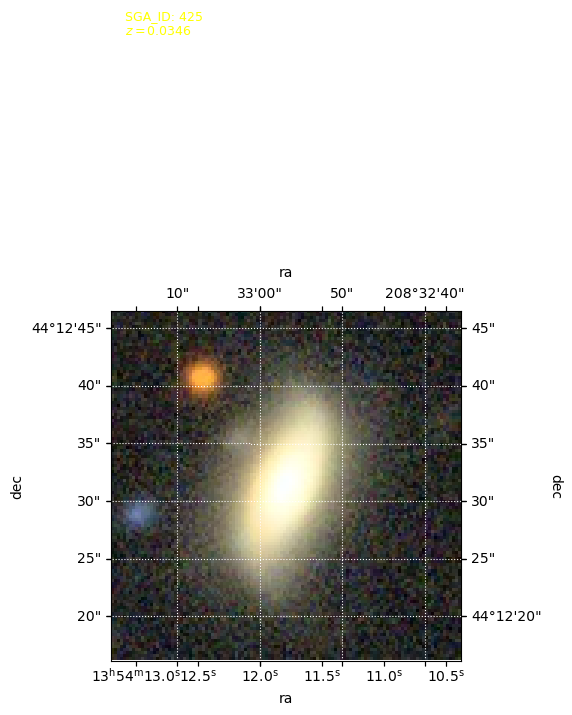

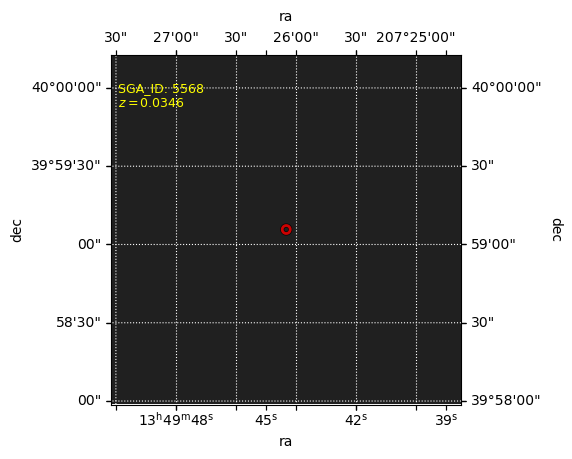

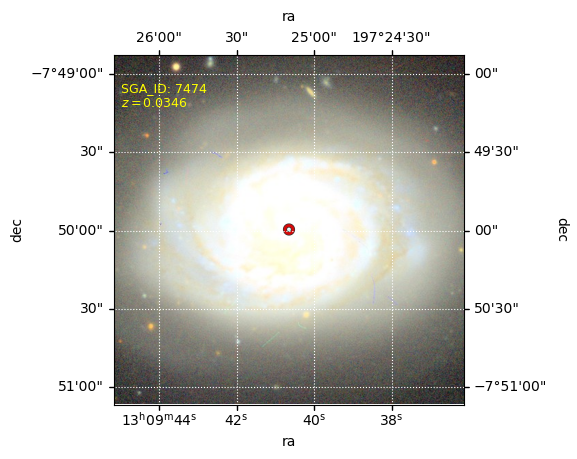

In [43]:
#FIXED FOR NEW EQUATION
# combine iron and fuji unique IDs
rot_curve_gals = np.unique(target_galaxies['SGA_ID'])

# for each rotation curve galaxy, grab cut out, draw fibers on image, and save image
for sga_id in rot_curve_gals[:3]:
    
    # targ_list = target_galaxies[target_galaxies['SGA_ID'] == sga_id]
    # if np.min(targ_list['DIST_R26']) < 0.001:
    #     center_target = targ_list[np.argmin(targ_list['DIST_R26'])]['TARGETID']
    #     z = targ_list[np.argmin(targ_list['DIST_R26'])]['Z']
        
    # else:
    #     continue
    
    ra, dec = float(SGA['RA'][SGA_dict[sga_id]]), float(SGA['DEC'][SGA_dict[sga_id]])
    
    # D26 in arcmin
    d26 = SGA['D26'][SGA_dict[sga_id]]
    

    npix = np.minimum(int(2 * d26*60/0.262), 512)
    

    img_file, wcs = get_cutout(sga_id, ra, dec, size=npix,verbose=True)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot(111, projection=wcs)
    ax.imshow(np.flip(img, axis=0))
    ax.set(xlabel='ra', ylabel='dec')
    ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}\n$z={{{:.4f}}}$'.format(sga_id, z), fontsize=9, color='yellow')
    overlay = ax.get_coords_overlay('icrs')
    overlay.grid(color='white', ls='dotted');

    # Add the location of the DESI fibers.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)

    for targ in targ_list:
        ra, dec = targ['TARGET_RA'], targ['TARGET_DEC']
        
        edgecolor2 = 'orange'

        # Add the location of the DESI fibers.
        # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
        r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                             transform=ax.get_transform('icrs'))
        r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                             transform=ax.get_transform('icrs'))
        ax.add_patch(r1)
        ax.add_patch(r2)
        
        ax.text(ra, dec, str(targ['TARGETID']), transform=ax.get_transform('icrs'), color='white', fontsize=6)
    
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    #fig1.savefig(vi_dir + '{}.png'.format(sga_id), dpi=120)
    
    #fig1.clear()
    #plt.close(fig1)
